# 02 — Data Exploration: UrbanSARFloods

**Goal:** Visually inspect chips, understand class distribution, validate that the DataLoader is reading everything correctly before training.

Run cells top to bottom. Change `DATA_ROOT` if your extraction path differs.

**Actual archive structure:**
```
urban_sar_floods/
  01_NF/SAR/*_SAR.tif   02_FO/SAR/*_SAR.tif   03_FU/SAR/*_SAR.tif
  01_NF/GT/*_GT.tif     02_FO/GT/*_GT.tif     03_FU/GT/*_GT.tif
```

In [1]:
import sys
sys.path.insert(0, '.')  # make src/ importable from notebooks/

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio

from src.data.dataset import UrbanSARFloodsDataset, make_splits, CLASS_NAMES, FOLDER_CLASS

DATA_ROOT = Path('data/urban_sar_floods')
assert DATA_ROOT.exists(), f'Dataset not found at {DATA_ROOT}. Did you extract urban_sar_floods.tar?'

## 1. Count chips per class folder

In [2]:
for folder in sorted(FOLDER_CLASS.keys()):
    sar_dir = DATA_ROOT / folder / 'SAR'
    gt_dir  = DATA_ROOT / folder / 'GT'
    chips = list(sar_dir.glob('*_SAR.tif')) if sar_dir.exists() else []
    masks = list(gt_dir.glob('*_GT.tif'))   if gt_dir.exists()  else []
    print(f'{folder}: {len(chips):4d} chips, {len(masks):4d} masks')

01_NF: 4770 chips, 4770 masks
02_FO: 1011 chips, 1011 masks
03_FU:  690 chips,  690 masks


## 2. Inspect a single chip — band statistics

In [3]:
# Pick first urban-flooded chip
sample_chip = sorted((DATA_ROOT / '03_FU' / 'SAR').glob('*_SAR.tif'))[0]
mask_name   = sample_chip.name.replace('_SAR.tif', '_GT.tif')
sample_mask = DATA_ROOT / '03_FU' / 'GT' / mask_name

with rasterio.open(sample_chip) as src:
    data = src.read().astype(float)   # (bands, H, W)
    profile = src.profile

print('Profile:', profile)
print(f'Shape: {data.shape}  dtype: {data.dtype}')
for i, band in enumerate(data):
    print(f'Band {i+1}: min={band.min():.2f}  max={band.max():.2f}  mean={band.mean():.2f}  std={band.std():.2f}')

Profile: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 512, 'height': 512, 'count': 8, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.00016666, 0.0, -96.44164218,
       0.0, -0.00016666, 30.197792040000003), 'blockxsize': 512, 'blockysize': 4, 'tiled': False, 'interleave': 'band'}
Shape: (8, 512, 512)  dtype: float64
Band 1: min=0.00  max=1.00  mean=0.37  std=0.16
Band 2: min=0.00  max=1.00  mean=0.45  std=0.17
Band 3: min=0.00  max=1.00  mean=0.22  std=0.17
Band 4: min=0.00  max=1.00  mean=0.29  std=0.19
Band 5: min=-60.00  max=6.99  mean=-15.51  std=3.45
Band 6: min=-60.00  max=6.99  mean=-10.67  std=3.83
Band 7: min=-55.13  max=6.99  mean=-13.70  std=3.19
Band 8: min

## 3. Visualize VV, VH, coherence, and GT mask

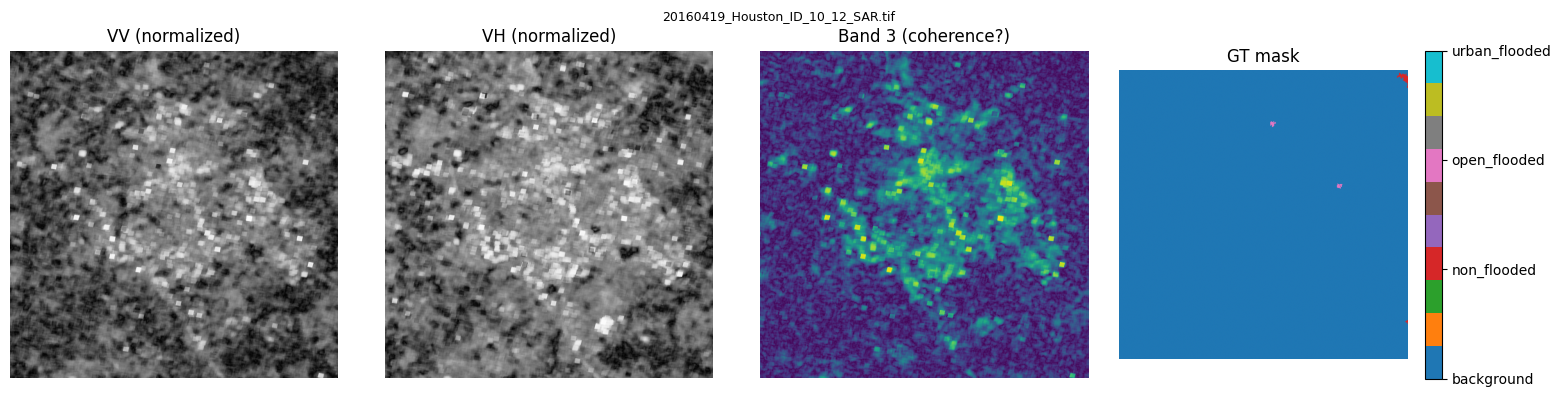

Unique mask values: [0. 1. 2.]


In [4]:
with rasterio.open(sample_mask) as src:
    mask = src.read(1)

DB_MIN, DB_MAX = -30.0, 5.0
vv      = np.clip(data[0], DB_MIN, DB_MAX)
vv_norm = (vv - DB_MIN) / (DB_MAX - DB_MIN)
vh      = np.clip(data[1], DB_MIN, DB_MAX)
vh_norm = (vh - DB_MIN) / (DB_MAX - DB_MIN)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(vv_norm, cmap='gray'); axes[0].set_title('VV (normalized)')
axes[1].imshow(vh_norm, cmap='gray'); axes[1].set_title('VH (normalized)')
if data.shape[0] >= 3:
    axes[2].imshow(np.clip(data[2], 0, 1), cmap='viridis')
    axes[2].set_title('Band 3 (coherence?)')
else:
    axes[2].text(0.5, 0.5, 'Only 2 bands', ha='center', va='center',
                 transform=axes[2].transAxes)
    axes[2].set_title('Band 3')
im = axes[3].imshow(mask, cmap='tab10', vmin=0, vmax=3)
axes[3].set_title('GT mask')
cbar = plt.colorbar(im, ax=axes[3], ticks=[0,1,2,3])
cbar.ax.set_yticklabels([CLASS_NAMES[c] for c in range(4)])

for ax in axes: ax.axis('off')
plt.suptitle(sample_chip.name, fontsize=9)
plt.tight_layout()
plt.show()
print('Unique mask values:', np.unique(mask))

## 4. Local variance — does it distinguish water from shadow?

Key hypothesis: shadow → near-zero variance (no signal returns). Water → low but non-zero variance (SAR speckle). Let's verify empirically.

Class                    Mean var   Median var   Pixels
--------------------------------------------------------
background               0.000002     0.000001   261821
non_flooded              0.000002     0.000002      205
open_flooded             0.000003     0.000002      118


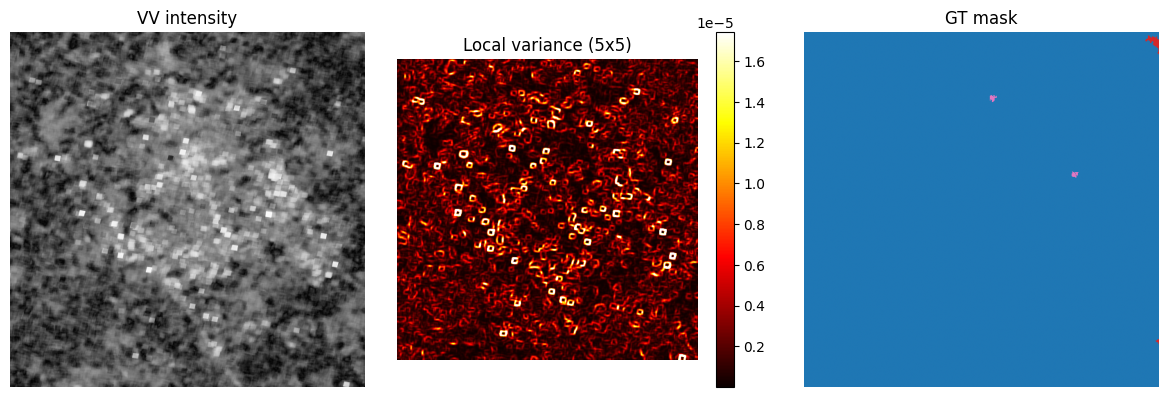

In [5]:
from scipy.ndimage import uniform_filter

def local_variance(arr, kernel=5):
    mean    = uniform_filter(arr, size=kernel)
    mean_sq = uniform_filter(arr**2, size=kernel)
    return np.maximum(mean_sq - mean**2, 0.0)

vv_var = local_variance(vv_norm)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(vv_norm, cmap='gray');                        axes[0].set_title('VV intensity')
im = axes[1].imshow(vv_var, cmap='hot',
                    vmax=np.percentile(vv_var, 99));          axes[1].set_title('Local variance (5x5)')
plt.colorbar(im, ax=axes[1])
axes[2].imshow(mask, cmap='tab10', vmin=0, vmax=3);          axes[2].set_title('GT mask')
for ax in axes: ax.axis('off')

print(f'{"Class":<20} {"Mean var":>12} {"Median var":>12} {"Pixels":>8}')
print('-' * 56)
for c, name in CLASS_NAMES.items():
    pixels = vv_var[mask == c]
    if len(pixels) > 0:
        print(f'{name:<20} {pixels.mean():>12.6f} {np.median(pixels):>12.6f} {len(pixels):>8}')

plt.tight_layout()
plt.show()

## 5. Class distribution across full dataset

**Note:** If you only extracted `02_FO` and `03_FU`, `01_NF` will show 0 — that's fine.

In [6]:
from collections import Counter
from tqdm.notebook import tqdm

print('Counting pixels across all GT masks (may take ~1 min)...')
pixel_counts = Counter()

for folder in FOLDER_CLASS.keys():
    gt_dir = DATA_ROOT / folder / 'GT'
    if not gt_dir.exists():
        print(f'  {folder}/GT not found — skipping')
        continue
    for mask_path in tqdm(sorted(gt_dir.glob('*_GT.tif')), desc=folder, leave=False):
        with rasterio.open(mask_path) as src:
            m = src.read(1).ravel()
        pixel_counts.update(m.tolist())

total = sum(pixel_counts.values())
print(f'\nTotal pixels counted: {total:,}')
print(f'{"Class":<20} {"Pixels":>14} {"Fraction":>10}')
for c in sorted(pixel_counts):
    name = CLASS_NAMES.get(int(c), f'class_{c}')
    frac = pixel_counts[c] / total
    print(f'{name:<20} {pixel_counts[c]:>14,} {frac:>10.4%}')

Counting pixels across all GT masks (may take ~1 min)...


01_NF:   0%|          | 0/4770 [00:00<?, ?it/s]

02_FO:   0%|          | 0/1011 [00:00<?, ?it/s]

03_FU:   0%|          | 0/690 [00:00<?, ?it/s]


Total pixels counted: 1,696,333,824
Class                        Pixels   Fraction
background            1,669,715,361   98.4308%
non_flooded              26,081,047    1.5375%
open_flooded                537,416    0.0317%


## 6. DataLoader smoke test

In [7]:
from torch.utils.data import DataLoader
from src.data.transforms import train_transforms

train_idx, val_idx = make_splits(DATA_ROOT)
print(f'Train: {len(train_idx)} chips  |  Val: {len(val_idx)} chips')

ds = UrbanSARFloodsDataset(
    root=DATA_ROOT,
    split_indices=train_idx[:50],
    transform=train_transforms(512),
    use_coherence=False,
    use_local_variance=True,
    binary=False,
)
print(f'n_channels={ds.n_channels}  n_classes={ds.n_classes}')

loader = DataLoader(ds, batch_size=2, shuffle=True, num_workers=0)
batch = next(iter(loader))

print(f"image shape : {batch['image'].shape}  dtype: {batch['image'].dtype}")
print(f"mask  shape : {batch['mask'].shape}   dtype: {batch['mask'].dtype}")
print(f"mask values : {batch['mask'].unique().tolist()}")
print(f"image range : [{batch['image'].min():.3f}, {batch['image'].max():.3f}]")
print('OK: DataLoader working')

Train: 5502 chips  |  Val: 969 chips
n_channels=4  n_classes=4
image shape : torch.Size([2, 4, 512, 512])  dtype: torch.float32
mask  shape : torch.Size([2, 512, 512])   dtype: torch.int64
mask values : [0]
image range : [0.000, 0.883]
OK: DataLoader working
